Loading the dataset
Dataset loaded successfully
Preparing the data
Calculated target as the average of High and Low columns
Dropped columns: ['Open', 'Close', 'Name', 'Symbol', 'SNo']
Processing the Date column
Date column converted to timestamp
Separating features and target
Features and target separated
Splitting the data into training and testing sets
Data split completed
Training the Linear Regression model
Model training completed
Making predictions on training and testing data
Predictions completed
Evaluating the model
Mean Absolute Error (MAE): 5.011871521403747e-06
Mean Squared Error (MSE): 9.13370840626643e-11
Generating future dates for prediction
Future dates generated: 60 days
Creating future data with placeholder values
Future data created with placeholder values
Future data columns reordered to match training data
Predicting future values
Future predictions completed
Plotting the results


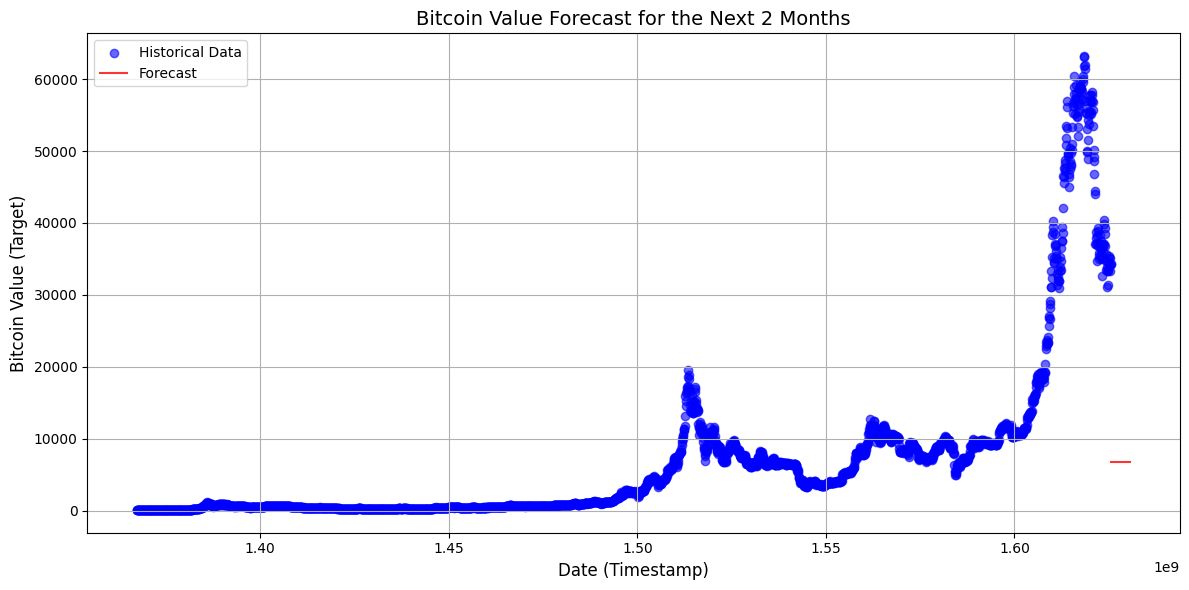

Plot displayed


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

print("Loading the dataset")
file_path = '10_coin_Bitcoin.xlsx'
bitcoin_data = pd.read_excel(file_path)
print("Dataset loaded successfully")

print("Preparing the data")
bitcoin_data['Target'] = (bitcoin_data['High'] + bitcoin_data['Low']) / 2
print("Calculated target as the average of High and Low columns")

columns_to_drop = ['Open', 'Close', 'Name', 'Symbol', 'SNo']
bitcoin_data = bitcoin_data.drop(columns=columns_to_drop)
print(f"Dropped columns: {columns_to_drop}")

print("Processing the Date column")
bitcoin_data['Date'] = pd.to_datetime(bitcoin_data['Date'])
bitcoin_data['Date'] = bitcoin_data['Date'].astype(np.int64) // 10**9
print("Date column converted to timestamp")

print("Separating features and target")
X = bitcoin_data.drop(columns=['Target'])
y = bitcoin_data['Target']
print("Features and target separated")

print("Splitting the data into training and testing sets")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Data split completed")

print("Training the Linear Regression model")
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training completed")

print("Making predictions on training and testing data")
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
print("Predictions completed")

print("Evaluating the model")
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")

print("Generating future dates for prediction")
future_dates = pd.date_range(start=pd.to_datetime(X['Date'].max(), unit='s'), periods=60, freq='D')
future_timestamps = future_dates.astype(np.int64) // 10**9
print(f"Future dates generated: {len(future_dates)} days")

print("Creating future data with placeholder values")
future_data = pd.DataFrame({
    'Date': future_timestamps,
    'High': [X['High'].mean()] * len(future_timestamps),
    'Low': [X['Low'].mean()] * len(future_timestamps),
    'Marketcap': [X['Marketcap'].mean()] * len(future_timestamps),
    'Volume': [X['Volume'].mean()] * len(future_timestamps)
})
print("Future data created with placeholder values")

future_data = future_data[X.columns]
print("Future data columns reordered to match training data")

print("Predicting future values")
future_predictions = model.predict(future_data)
print("Future predictions completed")

print("Plotting the results")
plt.figure(figsize=(12, 6))
plt.scatter(X['Date'], y, color='blue', label='Historical Data', alpha=0.6)
plt.plot(future_data['Date'], future_predictions, color='red', label='Forecast', alpha=0.8)
plt.xlabel("Date (Timestamp)", fontsize=12)
plt.ylabel("Bitcoin Value (Target)", fontsize=12)
plt.title("Bitcoin Value Forecast for the Next 2 Months", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Plot displayed")
